# Agents: Adding tools to an agent
---

`Tools` are an abstraction in LangChain that associates a python function with a schema that defines the function's name, description and expected arguments. `Tools` can then be passed to chat models that support `tool calling` allowing the model to request the execution of that function with the required parameters as provided in the schema.

#### What is Tool Calling?

Many AI applications interact directly with humans but what if there was a way for Large Language Models (`LLMs`) to interact directly with systems, such as your databases or external APIs? These systems often have a specific input schema, for example APIs frequently require a payload structure. For this, tool calling enables this functionality:

1. **Tool Creation**: Use the `@tool` decorator to create a tool. A tool is an association between a function and its respective schema.

1. **Tool Binding**: The tool needs to be connected to a model that supports tool calling. This gives model the awareness of the tool and the associated input schema that is required.

1. **Tool Calling**: When appropriate, the model can decide to call a tool and ensure its response conforms to the tool's output schema.

2. **Tool Execution**: The tool can be executed using the arguments provided by the model.

In this short lab, we will see how we can create tools, use tools and use that within our simple agent. We will use the same example from our previous notebook to create a simple agent with certain tools. 

### Set up and imports

In [1]:
# first, lets import the necessary libraries required to build the agent in this notebook
from typing import TypedDict, Annotated, List, Optional
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display

### Step 1: Define the Agent State

We will first define the agent state that will remain throughout the operation. This is the state of the graph and the state schema serves as the input for all nodes and edges in the graph.

In [2]:
class PlannerState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], "The messages in the conversation"]
    itinerary: Optional[str]
    city: str
    user_message: str
    weather_info: Optional[str]
    attractions_info: Optional[str]

### Step 2: Set up language models and prompts

Next, we will set up LLM and a prompt template that will be used by our agent in planning the trip.

In [3]:
# represents the global variables used across this notebook
BEDROCK_RUNTIME: str = 'bedrock-runtime'
# Model ID used by the agent
AMAZON_NOVA_LITE_MODEL_ID: str = "us.amazon.nova-lite-v1:0"
PROVIDER_ID : str = 'amazon'
# Inference parameters
TEMPERATURE: float = 0.1
MAX_TOKENS: int = 512

In [4]:
import boto3
import logging
# We are importing this to use any model supported on Amazon Bedrock. In this example
# we will be using the Amazon Nova lite model.
from langchain_aws import ChatBedrockConverse
# This helps checkpoint the memory state of the agent for short term/long term memory
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables.config import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [5]:
# set a logger
logging.basicConfig(format='[%(asctime)s] p%(process)s {%(filename)s:%(lineno)d} %(levelname)s - %(message)s', level=logging.INFO)
logger = logging.getLogger(__name__)

In [6]:
session = boto3.session.Session()
region = session.region_name
logger.info(f"Running this example in region: {region}")

# Initialize the bedrock client placeholder
bedrock_client = boto3.client("bedrock-runtime")

[2025-03-27 12:59:02,820] p38942 {2342708946.py:3} INFO - Running this example in region: us-west-2
[2025-03-27 12:59:02,833] p38942 {credentials.py:1352} INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [18]:
# Create the llm used by the agent
llm = ChatBedrockConverse(
    model=AMAZON_NOVA_LITE_MODEL_ID,
    provider=PROVIDER_ID, 
    temperature=TEMPERATURE, 
    max_tokens=MAX_TOKENS,
    client=bedrock_client,
)

In [19]:
from langchain_core.prompts import PromptTemplate

# Define the correct ReAct prompt template
template = '''You are a helpful travel assistant. Create a day trip itinerary for {city} based on the user's interests.

You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final itinerary

Begin!

Question: {input}
Thought:{agent_scratchpad}'''

### Create tools and binding them to an LLM
---

In this section of the notebook, we have now created the `llm` (using `Amazon Nova Lite`). `Amazon Nova Lite` supports function calling. In this case, we can create a function or tools with the `@tool` decorator and associate these tools to the `llm`. The `llm` will then use the tools during invocation and determine which tool to use when a user asks a question.


```python
# Tool creation
tools = [my_tool]
# Tool binding
model_with_tools = model.bind_tools(tools)
# Tool calling 
response = model_with_tools.invoke(user_input)
```

Now, we will create two tools that our `LLM` will have access to while executing the user request:

1. **Search tourist attractions**: We will create a function that does a web search using the `TAVILY` API. This API will be used with the city as requested by the user to look for tourist attractions.

1. **Get weather forecast**: This tool will be used to get insights into the current weather in the city as requested by the user for which they are wanting to create an itinerary.

In [20]:
import os
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")  
WEATHER_API_KEY = os.environ.get("WEATHER_API_KEY")

In [ ]:
from langchain_core.tools import tool
import requests

@tool
def search_tourist_attractions(city: str) -> str:
    """
    Search for tourist attractions in the specified city using the Tavily API.
    
    Args:
        city: The name of the city to search for attractions
        
    Returns:
        A string containing information about tourist attractions in the city
    """
    if not TAVILY_API_KEY:
        return f"Unable to search for tourist attractions in {city} because the Tavily API key is not set."
    
    try:
        # Using Tavily API for web search
        url = "https://api.tavily.com/search"
        params = {
            "api_key": TAVILY_API_KEY,
            "query": f"top tourist attractions in {city} for boating and swimming",
            "search_depth": "advanced",
            "include_domains": ["tripadvisor.com", "lonelyplanet.com", "timeout.com", "viator.com"],
            "max_results": 5
        }
        
        response = requests.get(url, params=params)
        response.raise_for_status()
        results = response.json()
        
        attractions = "Top boating and swimming attractions:\n"
        for i, result in enumerate(results.get("results", []), 1):
            attractions += f"{i}. {result.get('title')}: {result.get('content')[:150]}...\n"
        
        return attractions
    
    except Exception as e:
        logger.error(f"Error searching for tourist attractions: {e}")
        return f"An error occurred while searching for tourist attractions in {city}. Please try again later."

@tool
def get_weather_forecast(city: str) -> str:
    """
    Get the current weather forecast for the specified city using the Weatherstack API.
    
    Args:
        city: The name of the city to get the weather forecast for
        
    Returns:
        A string containing the weather forecast for the city
    """
    if not WEATHER_API_KEY:
        return f"Unable to get weather forecast for {city} because the Weatherstack API key is not set."
    
    try:
        # Using Weatherstack API for weather data
        url = "http://api.weatherstack.com/current"
        params = {
            "access_key": WEATHER_API_KEY,
            "query": city,
            "units": "m"  # Use metric units
        }
        
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        
        # Check if the API returned an error
        if "success" in data and data["success"] is False:
            error_info = data["error"]["info"]
            logger.error(f"Weatherstack API error: {error_info}")
            return f"Error from weather service: {error_info}"
        
        # Extract weather information from the response
        location = data["location"]
        current = data["current"]
        
        # Format the weather information
        forecast = f"Current weather in {location['name']}, {location['country']}:\n"
        forecast += f"Local time: {location['localtime']}\n"
        forecast += f"Temperature: {current['temperature']}°C\n"
        forecast += f"Weather: {', '.join(current['weather_descriptions'])}\n"
        forecast += f"Feels like: {current['feelslike']}°C\n"
        forecast += f"Humidity: {current['humidity']}%\n"
        forecast += f"Wind: {current['wind_speed']} km/h, {current['wind_dir']}\n"
        forecast += f"Pressure: {current['pressure']} mb\n"
        forecast += f"Visibility: {current['visibility']} km\n"
        forecast += f"UV Index: {current['uv_index']}\n"
        
        # Add precipitation information if available
        if 'precip' in current:
            forecast += f"Precipitation: {current['precip']} mm\n"
            
        # Add cloud cover information if available
        if 'cloudcover' in current:
            forecast += f"Cloud cover: {current['cloudcover']}%\n"
            
        # Add air quality information if available
        if 'air_quality' in current:
            aq = current['air_quality']
            forecast += "\nAir Quality:\n"
            forecast += f"US EPA Index: {aq['us-epa-index']} "
            
            # Add interpretation of EPA index
            epa_index = aq['us-epa-index']
            if epa_index == "1":
                forecast += "(Good)\n"
            elif epa_index == "2":
                forecast += "(Moderate)\n"
            elif epa_index == "3":
                forecast += "(Unhealthy for sensitive groups)\n"
            elif epa_index == "4":
                forecast += "(Unhealthy)\n"
            elif epa_index == "5":
                forecast += "(Very Unhealthy)\n"
            elif epa_index == "6":
                forecast += "(Hazardous)\n"
            else:
                forecast += "\n"
                
        return forecast
    
    except Exception as e:
        logger.error(f"Error getting weather forecast: {e}")
        return f"An error occurred while getting the weather forecast for {city}. Please try again later."


In [22]:
tools = [search_tourist_attractions, get_weather_forecast]

In [24]:
from langgraph.prebuilt import create_react_agent

# Create the proper prompt
react_prompt = PromptTemplate.from_template(template)

# Create the ReAct agent with the correct prompt
get_realtime_info_react_llm = create_react_agent(
    llm,
    tools=tools,
    prompt=react_prompt
)

### Define the nodes and Edges
---

Next, we will be adding nodes, edges and persistent memory to the `StateGraph` before we compile it.

1. user travel plans
1. invoke with Bedrock
1. generate the travel plan for the day
1. ability to add or modify the plan

In [25]:
# The first node that solely inputs a user message
# The first node that takes in user input
def input_interest(state: PlannerState) -> PlannerState:
    """
    This function processes the user's message.
    """
    logger.info(f"Processing input for city: {state.get('city', 'unknown')}")
    
    # Initialize messages if needed
    if not state.get('messages'): 
        state['messages'] = []
    
    # Return updated state
    return {
        **state
    }

def create_itinerary(state: PlannerState) -> PlannerState:
    try:
        # Only pass the user message as input
        agent_input = {
            "input": state['user_message'],
            "city": state['city']
        }
        
        # Invoke the agent
        result = get_realtime_info_react_llm.invoke(agent_input)
        
        # Extract the output
        if isinstance(result, dict) and "output" in result:
            itinerary = result["output"]
        else:
            itinerary = str(result)
        
        # Return state
        return {
            **state,
            'messages': [
                *state['messages'],
                HumanMessage(content=state['user_message']),
                AIMessage(content=itinerary)
            ],
            'itinerary': itinerary
        }
    except Exception as e:
        logger.error(f"Error creating itinerary: {e}")
        error_message = f"I apologize, but I encountered an error while creating your itinerary: {str(e)}"
        
        # Print the exception for debugging
        import traceback
        traceback.print_exc()
        
        # Return updated state with error
        return {
            **state,
            'messages': [
                *state['messages'],
                HumanMessage(content=state['user_message']),
                AIMessage(content=error_message)
            ],
            'itinerary': error_message
        }


### Create and Compile the Graph
---

In this portion of the notebook, we will create our `LangGraph` workflow and then compile it.

1. First, we will initialize the `StateGraph` with the `State` class that we defined above
1. Then, we add our nodes and edges.
1. We use the `START` Node, a special node that sends user input to the graph, to indicate where to start our graph.
1. The `END` Node is a special node that represents a terminal node.

In [26]:
# initialize the StateGraph
workflow = StateGraph(PlannerState)
# Next, we will add our nodes to this workflowa
workflow.add_node("input_user_interests", input_interest)
workflow.add_node("create_itinerary", create_itinerary)
workflow.set_entry_point("input_user_interests")
# Next, we will add a direct edge between input interests and create itinerary
workflow.add_edge("input_user_interests", "create_itinerary")
workflow.add_edge("create_itinerary", END)

In [27]:
# Next, we create a checkpointer which will let us have the graph persist its state
# this is a complete memory for the entire graph
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

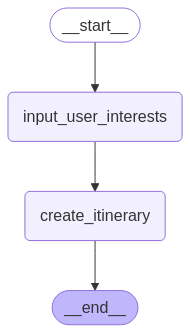

In [28]:
# Now that we have compiled the graph, we can view it in a mermaid diagram. You can use Mermaid
# to generate diagrams from markdown-like text.

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

From the graph above, we can see that from the start point, the user can input the message or their interests for the itinerary. Next, according to the next node, the llm will be invoked with the custom prompt template to create that itinerary. This is a hello world example of a simple agent on `LangGraph`.

### Define the function that runs the graph
---

When we compile the graph, we turn it into a `LangChain` Runnable, which automatically enables calling `.invoke()`, `.stream()` and `.batch()` with your inputs. In the following example, we run `stream()` to invoke the graph with inputs

In [29]:
def run_travel_planner(user_request: str, city_request: str, config_dict: dict):
    print(f"Current User Request: {user_request}\n")
    print(f"City of interest: {city_request}\n")
    init_input = {"user_message": user_request,"city" : city_request}

    for output in app.stream(init_input, config=config_dict, stream_mode="values"):
        pass  # The nodes themselves now handle all printing

In [30]:
# lets run the example

# thread_id within the configurable object serves as a unique identifier for the conversation session. This ID is used by the graph to: Track which conversation a message belongs to and
# maintain separate conversation histories for different users or sessions
config = {"configurable": {"thread_id": "2"}}

# I want to create an itinerary for a day trip in NYC with boating and swimming options. Make it extremely comprehensive and should include meals as well. Need the weather as well
user_request = input("Enter your travel request: ")
city = input("Enter the city: ")

# Use them in the function call
run_travel_planner(user_request, city, config)

[2025-03-27 13:09:49,428] p38942 {140729203.py:7} INFO - Processing input for city: nyc
[2025-03-27 13:09:49,442] p38942 {140729203.py:46} ERROR - Error creating itinerary: "Input to PromptTemplate is missing variables {'agent_scratchpad', 'city', 'input', 'tool_names', 'tools'}.  Expected: ['agent_scratchpad', 'city', 'input', 'tool_names', 'tools'] Received: ['messages', 'is_last_step', 'remaining_steps']\nNote: if you intended {agent_scratchpad} to be part of the string and not a variable, please escape it with double curly braces like: '{{agent_scratchpad}}'.\nFor troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_PROMPT_INPUT "


Current User Request: I want to create an itinerary for a day trip in NYC with boating and swimming options. Make it extremely comprehensive and should include meals as well. Need the weather as well

City of interest: nyc



Traceback (most recent call last):
  File "/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_38942/140729203.py", line 27, in create_itinerary
    result = get_realtime_info_react_llm.invoke(agent_input)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langgraph/pregel/__init__.py", line 2375, in invoke
    for chunk in self.stream(
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langgraph/pregel/__init__.py", line 2031, in stream
    for _ in runner.tick(
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langgraph/pregel/runner.py", line 230, in tick
    run_with_retry(
  File "/Users/madhurpt/Desktop/langGraph-AWS-incident-response-1/scratchpad_examples/.venv/lib/python3.12/site-packages/langgraph/prege